# 📊 Stock Portfolio Analysis & Risk Assessment

This project analyzes a portfolio of stocks to evaluate performance, risk, and diversification.

### Objectives:
- Analyze stock returns and volatility
- Measure risk-adjusted performance (Sharpe Ratio)
- Evaluate drawdowns and market sensitivity (Beta)
- Understand diversification using correlation
- Analyze portfolio-level performance

In [1]:
# ==============================
# 📦 Imports
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

import os
import time

plt.style.use('seaborn-v0_8')

TRADING_DAYS = 252
RISK_FREE_RATE = 0.02

In [2]:
# ==============================
# 📁 Folder Setup (FIXED)
# ==============================

# Get project root (go one level up from notebook folder)
BASE_DIR = os.path.dirname(os.getcwd())

DATA_DIR = os.path.join(BASE_DIR, "data")
RAW_DIR = os.path.join(DATA_DIR, "raw")
PROCESSED_DIR = os.path.join(DATA_DIR, "processed")

os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)

In [3]:
# ==============================
# 📊 Data Collection
# ==============================

tickers = ['AAPL', 'MSFT', 'GOOGL', 'TSLA', 'JPM', 'PFE', 'WMT', 'VTI']

price_data = {}

for ticker in tickers:
    print(f"Downloading {ticker}...")
    
    # ==============================
# 📊 Data Collection
# ==============================

tickers = ['AAPL', 'MSFT', 'GOOGL', 'TSLA', 'JPM', 'PFE', 'WMT', 'VTI']

price_data = {}

for ticker in tickers:
    print(f"Downloading {ticker}...")
    
    try:
        df = yf.download(ticker, start="2019-01-01", end="2025-12-31")
        
        # Check if data exists
        if df.empty:
            print(f"No data for {ticker}")
            continue
        
        # Save raw data
        file_path = os.path.join(RAW_DIR, f"{ticker}.csv")
        df.to_csv(file_path)
        
        # Handle MultiIndex
        if isinstance(df.columns, pd.MultiIndex):
            close_prices = df['Close'][ticker]
        else:
            close_prices = df['Close']
        
        # Store clean data
        price_data[ticker] = close_prices
        
        time.sleep(1)
        
    except Exception as e:
        print(f"Error with {ticker}: {e}")

print("Collected:", list(price_data.keys()))

[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


Collected: ['AAPL', 'MSFT', 'GOOGL', 'TSLA', 'JPM', 'PFE', 'WMT', 'VTI']


In [4]:
# ==============================
# 🔗 Combine Data
# ==============================

prices = pd.concat(price_data, axis=1)

# Fix date index
prices.index = pd.to_datetime(prices.index, errors='coerce')
prices = prices.dropna()

prices.head()

,AAPL,MSFT,GOOGL,TSLA,JPM,PFE,WMT,VTI
Date,,,,,,,,
2019-01-02,37.503723,94.397171,52.301731,20.674667,81.250214,29.294357,27.967047,114.742310
2019-01-03,33.768093,90.924461,50.853195,20.024000,80.095505,28.474789,27.823225,112.083275
2019-01-04,35.209614,95.153282,53.461643,21.179333,83.048264,29.125027,27.997013,115.793304
2019-01-07,35.131248,95.274651,53.355030,22.330667,83.105980,29.280823,28.326591,116.961128
2019-01-08,35.800953,95.965469,53.823654,22.356667,82.949272,29.416277,28.524355,118.164879


In [5]:
output_path = os.path.join(PROCESSED_DIR, "portfolio_prices_clean.csv")
prices.to_csv(output_path)

In [6]:
# ==============================
# 📈 Daily Returns
# ==============================

returns = prices.pct_change().dropna()
returns.head()

,AAPL,MSFT,GOOGL,TSLA,JPM,PFE,WMT,VTI
Date,,,,,,,,
2019-01-03,-0.099607,-0.036788,-0.027696,-0.031472,-0.014212,-0.027977,-0.005143,-0.023174
2019-01-04,0.042689,0.046509,0.051294,0.057697,0.036865,0.022836,0.006246,0.033101
2019-01-07,-0.002226,0.001276,-0.001994,0.054361,0.000695,0.005349,0.011772,0.010085
2019-01-08,0.019063,0.007251,0.008783,0.001164,-0.001886,0.004626,0.006982,0.010292
2019-01-09,0.016982,0.014299,-0.003428,0.009483,-0.001690,-0.002072,-0.003256,0.004714


In [7]:
# ==============================
# 📊 Financial Metrics
# ==============================

annual_returns = returns.mean() * TRADING_DAYS
volatility = returns.std() * np.sqrt(TRADING_DAYS)
sharpe_ratio = annual_returns / volatility

In [8]:
# ==============================
# 📉 Max Drawdown
# ==============================

cumulative = (1 + returns).cumprod()
peak = cumulative.cummax()
drawdown = (cumulative - peak) / peak

max_drawdown = drawdown.min()

In [9]:
metrics = pd.DataFrame({
    "Annual Return": annual_returns,
    "Volatility": volatility,
    "Sharpe Ratio": sharpe_ratio,
    "Max Drawdown": max_drawdown
})

metrics.sort_values("Sharpe Ratio", ascending=False)

,Annual Return,Volatility,Sharpe Ratio,Max Drawdown
AAPL,0.332813,0.310852,1.070647,-0.333605
WMT,0.222672,0.219777,1.013171,-0.257397
TSLA,0.649451,0.643442,1.009338,-0.736322
GOOGL,0.306072,0.313764,0.975482,-0.443201
MSFT,0.275331,0.283732,0.970388,-0.371485
VTI,0.175403,0.202465,0.866334,-0.350003
JPM,0.242009,0.298990,0.809423,-0.436265
PFE,0.009104,0.262187,0.034721,-0.589620


In [10]:
# ==============================
# 📉 Beta Calculation
# ==============================

market_returns = returns['VTI']

beta = {}

for stock in returns.columns:
    cov = np.cov(returns[stock], market_returns)[0][1]
    beta[stock] = cov / market_returns.var()

beta = pd.Series(beta)
beta

AAPL     1.173487
MSFT     1.106053
GOOGL    1.101241
TSLA     1.680550
JPM      1.057739
PFE      0.519300
WMT      0.457546
VTI      1.000000
dtype: float64

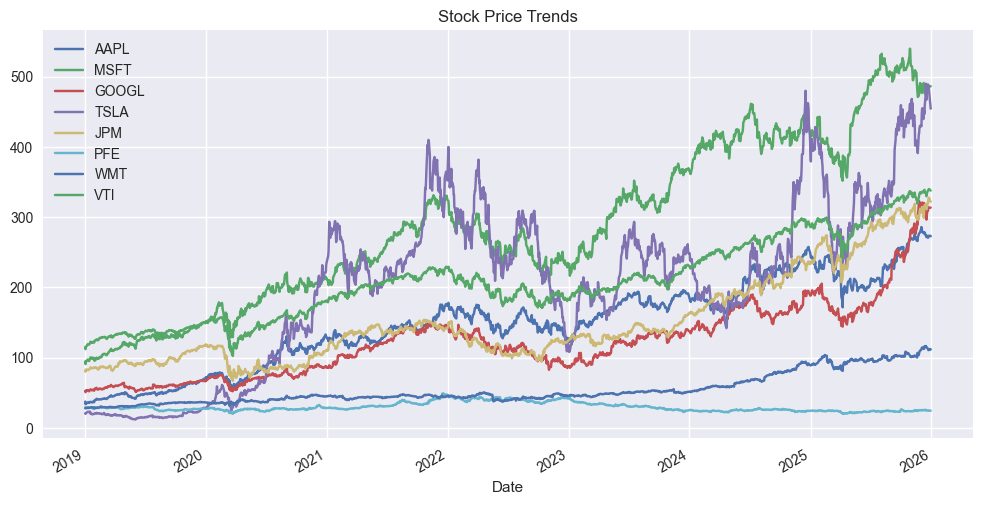

In [11]:
prices.plot(figsize=(12,6))
plt.title("Stock Price Trends")
plt.show()

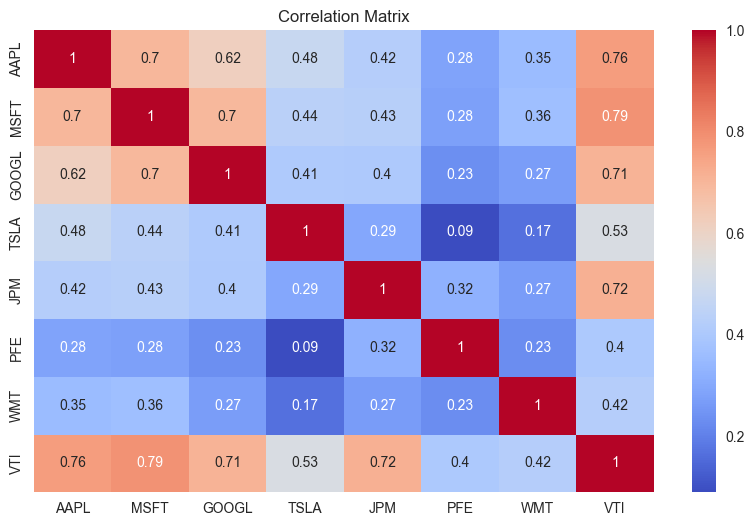

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(returns.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

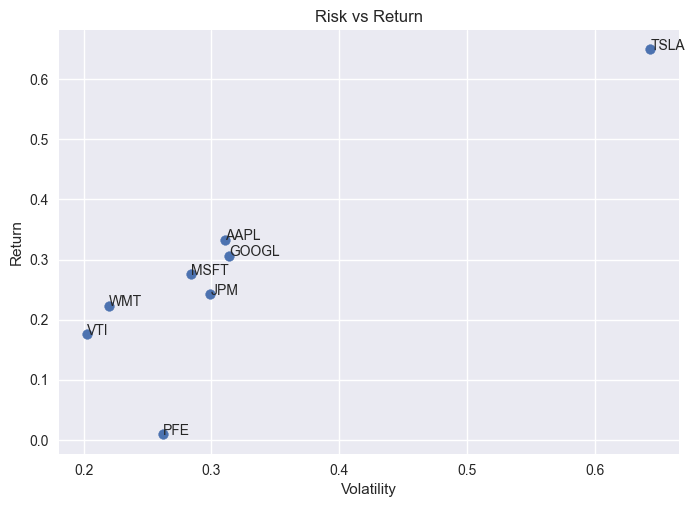

In [13]:
plt.scatter(volatility, annual_returns)

for i in metrics.index:
    plt.text(volatility[i], annual_returns[i], i)

plt.xlabel("Volatility")
plt.ylabel("Return")
plt.title("Risk vs Return")
plt.show()

In [14]:
# ==============================
# 💼 Portfolio Analysis
# ==============================

weights = np.array([0.15,0.15,0.15,0.10,0.10,0.10,0.10,0.15])

portfolio_returns = returns.dot(weights)

portfolio_return = portfolio_returns.mean() * TRADING_DAYS
portfolio_volatility = portfolio_returns.std() * np.sqrt(TRADING_DAYS)

portfolio_return, portfolio_volatility

(np.float64(0.27576613945164613), np.float64(0.22451540491912958))

In [15]:
import os

# Get project root (go one level up from notebook)
BASE_DIR = os.path.dirname(os.getcwd())

IMAGES_PATH = os.path.join(BASE_DIR, "images")
os.makedirs(IMAGES_PATH, exist_ok=True)

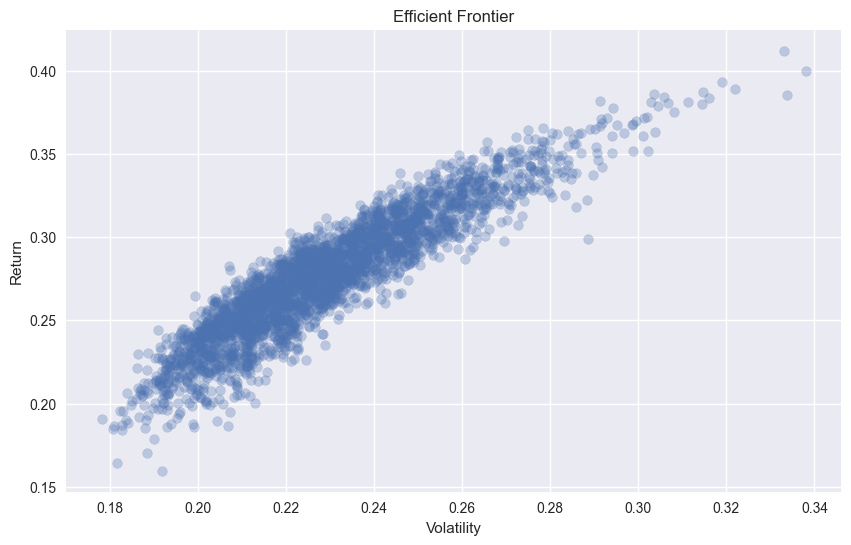

In [16]:
# ==============================
# 🚀 Efficient Frontier
# ==============================

num_portfolios = 3000

results = []

for _ in range(num_portfolios):
    w = np.random.random(len(tickers))
    w /= np.sum(w)
    
    ret = np.dot(w, annual_returns)
    vol = np.sqrt(np.dot(w.T, np.dot(returns.cov()*252, w)))
    
    results.append([ret, vol])

results = np.array(results)

plt.figure(figsize=(10,6))
plt.scatter(results[:,1], results[:,0], alpha=0.3)

plt.xlabel("Volatility")
plt.ylabel("Return")
plt.title("Efficient Frontier")
plt.grid(True)
plt.savefig(os.path.join(IMAGES_PATH, "efficient_frontier.png"))
plt.show()

## 🔍 Key Insights

- TSLA exhibits high return and high volatility, indicating higher risk
- Defensive stocks like WMT and PFE provide more stable performance
- Strong correlations among tech stocks reduce diversification benefits
- Portfolio risk depends not only on individual stocks but also their relationships
- Different weight combinations can significantly impact risk-return outcomes

## 📌 Conclusion

This project demonstrates how portfolio performance can be evaluated using financial metrics and data analysis techniques.

It highlights the importance of diversification, risk management, and asset allocation in portfolio construction.

In [17]:
prices.info()
prices.head()
prices.tail()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1759 entries, 2019-01-02 to 2025-12-30
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    1759 non-null   float64
 1   MSFT    1759 non-null   float64
 2   GOOGL   1759 non-null   float64
 3   TSLA    1759 non-null   float64
 4   JPM     1759 non-null   float64
 5   PFE     1759 non-null   float64
 6   WMT     1759 non-null   float64
 7   VTI     1759 non-null   float64
dtypes: float64(8)
memory usage: 123.7 KB


,AAPL,MSFT,GOOGL,TSLA,JPM,PFE,WMT,VTI
Date,,,,,,,,
2025-12-23,272.105377,485.741333,314.128876,485.559998,324.466400,24.470098,110.672867,338.720001
2025-12-24,273.554016,486.908630,313.869049,485.399994,327.691864,24.617630,111.381416,339.880005
2025-12-26,273.144409,486.599365,313.289459,475.190002,326.437531,24.676640,111.511147,339.670013
2025-12-29,273.504089,485.990753,313.339417,459.640015,322.296204,24.588123,112.299530,338.390015
2025-12-30,272.824707,486.369904,313.629242,454.429993,321.967712,24.578287,111.690781,337.850006


In [18]:
returns = prices.pct_change().dropna()
returns.head()

,AAPL,MSFT,GOOGL,TSLA,JPM,PFE,WMT,VTI
Date,,,,,,,,
2019-01-03,-0.099607,-0.036788,-0.027696,-0.031472,-0.014212,-0.027977,-0.005143,-0.023174
2019-01-04,0.042689,0.046509,0.051294,0.057697,0.036865,0.022836,0.006246,0.033101
2019-01-07,-0.002226,0.001276,-0.001994,0.054361,0.000695,0.005349,0.011772,0.010085
2019-01-08,0.019063,0.007251,0.008783,0.001164,-0.001886,0.004626,0.006982,0.010292
2019-01-09,0.016982,0.014299,-0.003428,0.009483,-0.001690,-0.002072,-0.003256,0.004714


In [19]:
TRADING_DAYS = 252

annual_returns = returns.mean() * TRADING_DAYS
volatility = returns.std() * np.sqrt(TRADING_DAYS)
sharpe_ratio = annual_returns / volatility

In [20]:
cumulative = (1 + returns).cumprod()
peak = cumulative.cummax()
drawdown = (cumulative - peak) / peak

max_drawdown = drawdown.min()

In [21]:
metrics = pd.DataFrame({
    "Annual Return": annual_returns,
    "Volatility": volatility,
    "Sharpe Ratio": sharpe_ratio,
    "Max Drawdown": max_drawdown
})

metrics.sort_values("Sharpe Ratio", ascending=False)

,Annual Return,Volatility,Sharpe Ratio,Max Drawdown
AAPL,0.332813,0.310852,1.070647,-0.333605
WMT,0.222672,0.219777,1.013171,-0.257397
TSLA,0.649451,0.643442,1.009338,-0.736322
GOOGL,0.306072,0.313764,0.975482,-0.443201
MSFT,0.275331,0.283732,0.970388,-0.371485
VTI,0.175403,0.202465,0.866334,-0.350003
JPM,0.242009,0.298990,0.809423,-0.436265
PFE,0.009104,0.262187,0.034721,-0.589620


In [22]:
market_returns = returns['VTI']

beta = {}

for stock in returns.columns:
    cov = np.cov(returns[stock], market_returns)[0][1]
    beta[stock] = cov / market_returns.var()

beta = pd.Series(beta)
beta

AAPL     1.173487
MSFT     1.106053
GOOGL    1.101241
TSLA     1.680550
JPM      1.057739
PFE      0.519300
WMT      0.457546
VTI      1.000000
dtype: float64

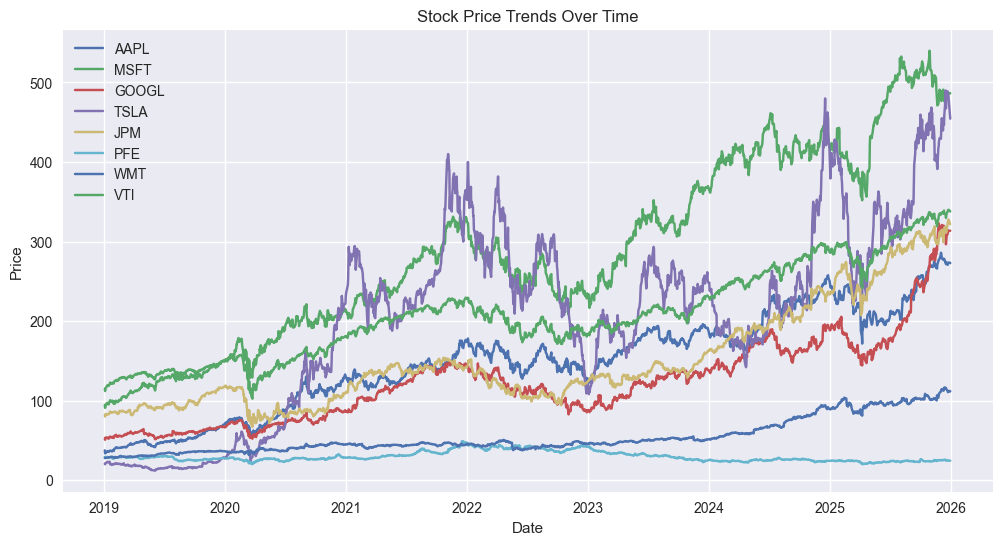

In [23]:
# ==============================
# 📈 Price Trends
# ==============================

plt.figure(figsize=(12,6))

for col in prices.columns:
    plt.plot(prices.index, prices[col], label=col)

plt.title("Stock Price Trends Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(IMAGES_PATH, "price_trends.png"))
plt.show()

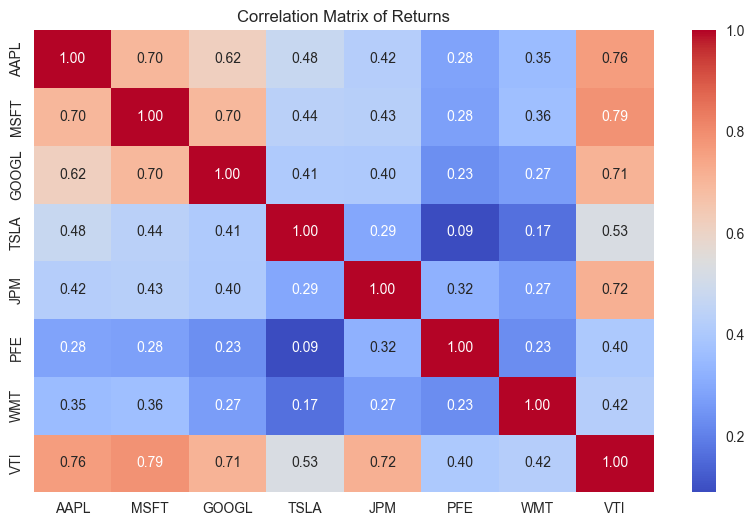

In [24]:
# ==============================
# 🔗 Correlation Heatmap
# ==============================

plt.figure(figsize=(10,6))

sns.heatmap(
    returns.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Returns")
plt.savefig(os.path.join(IMAGES_PATH, "correlation_heatmap.png"))
plt.show()

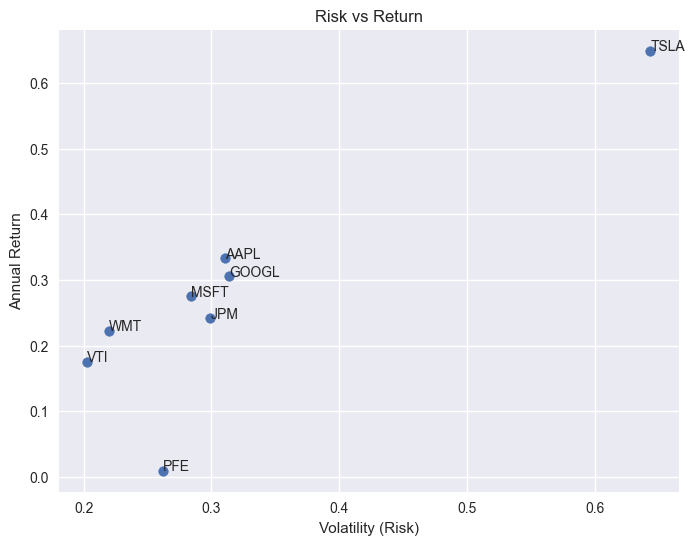

In [25]:
# ==============================
# 📊 Risk vs Return
# ==============================

plt.figure(figsize=(8,6))

plt.scatter(volatility, annual_returns)

for i in metrics.index:
    plt.text(volatility[i], annual_returns[i], i)

plt.xlabel("Volatility (Risk)")
plt.ylabel("Annual Return")
plt.title("Risk vs Return")
plt.grid(True)
plt.savefig(os.path.join(IMAGES_PATH, "risk_return.png"))
plt.show()

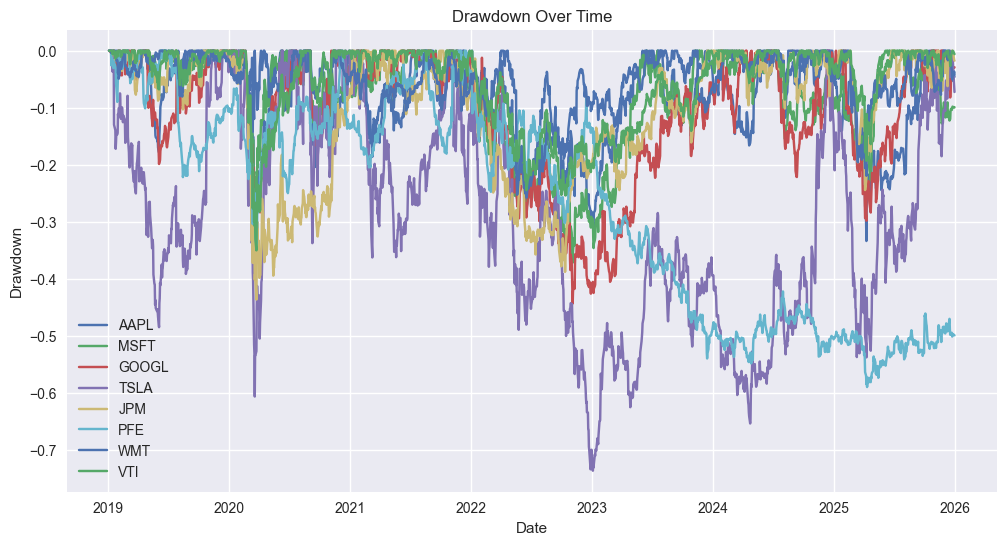

In [26]:
# ==============================
# 📉 Drawdown
# ==============================

plt.figure(figsize=(12,6))

for col in drawdown.columns:
    plt.plot(drawdown.index, drawdown[col], label=col)

plt.title("Drawdown Over Time")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(IMAGES_PATH, "drawdown.png"))
plt.show()

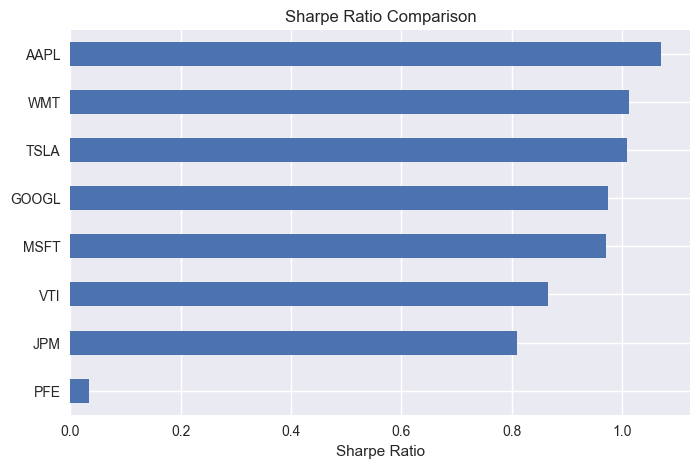

In [27]:
# ==============================
# 📊 Sharpe Ratio Comparison
# ==============================

sharpe_ratio.sort_values().plot(kind='barh', figsize=(8,5))
plt.style.use('seaborn-v0_8')
plt.title("Sharpe Ratio Comparison")
plt.xlabel("Sharpe Ratio")

plt.show()

In [28]:
# ==============================
# 💼 Portfolio Weights
# ==============================

weights = np.array([0.15, 0.15, 0.15, 0.10, 0.10, 0.10, 0.10, 0.15])

# Check sum = 1
print("Total Weight:", weights.sum())

Total Weight: 1.0


In [29]:
# ==============================
# 📈 Portfolio Returns
# ==============================

portfolio_returns = returns.dot(weights)

portfolio_returns.head()

Date
2019-01-03   -0.035970
2019-01-04    0.038403
2019-01-07    0.008289
2019-01-08    0.007897
2019-01-09    0.005131
dtype: float64

In [30]:
# ==============================
# 📊 Portfolio Metrics
# ==============================

portfolio_annual_return = portfolio_returns.mean() * 252
portfolio_volatility = portfolio_returns.std() * np.sqrt(252)
portfolio_sharpe = portfolio_annual_return / portfolio_volatility

print("Portfolio Return:", portfolio_annual_return)
print("Portfolio Volatility:", portfolio_volatility)
print("Portfolio Sharpe Ratio:", portfolio_sharpe)

Portfolio Return: 0.27576613945164613
Portfolio Volatility: 0.22451540491912958
Portfolio Sharpe Ratio: 1.2282726860144721


In [31]:
# ==============================
# 📉 Portfolio Drawdown
# ==============================

portfolio_cumulative = (1 + portfolio_returns).cumprod()
portfolio_peak = portfolio_cumulative.cummax()
portfolio_drawdown = (portfolio_cumulative - portfolio_peak) / portfolio_peak

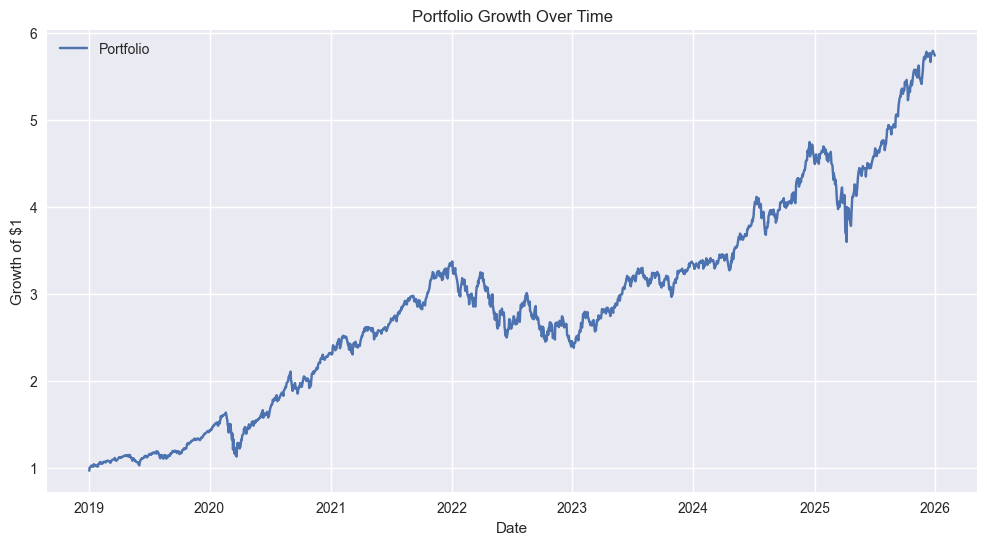

In [32]:
# ==============================
# 📊 Portfolio Performance
# ==============================

plt.figure(figsize=(12,6))

plt.plot(portfolio_cumulative, label="Portfolio")

plt.title("Portfolio Growth Over Time")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(IMAGES_PATH, "portfolio_growth.png"))
plt.show()

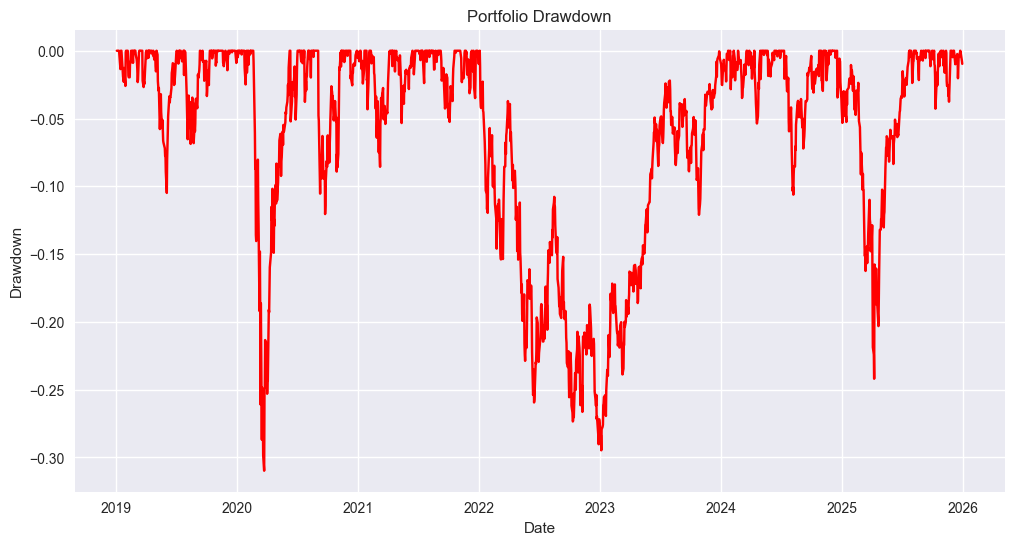

In [33]:
plt.figure(figsize=(12,6))

plt.plot(portfolio_drawdown, color='red')

plt.title("Portfolio Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")

plt.grid(True)
plt.show()

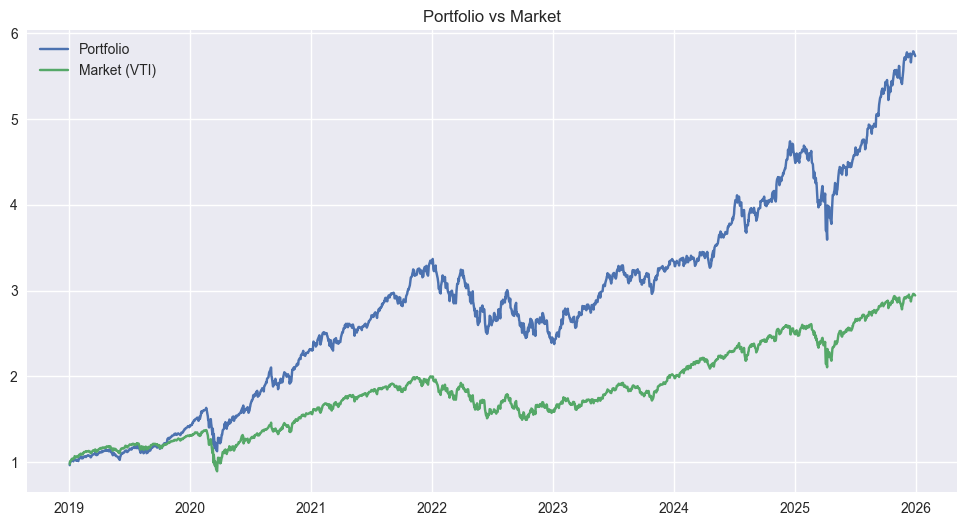

In [34]:
# ==============================
# 📊 Portfolio vs Market
# ==============================

market_cumulative = (1 + returns['VTI']).cumprod()

plt.figure(figsize=(12,6))

plt.plot(portfolio_cumulative, label="Portfolio")
plt.plot(market_cumulative, label="Market (VTI)")

plt.title("Portfolio vs Market")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(IMAGES_PATH, "Portfolio_VS_Market.png"))
plt.show()

## 🔍 Portfolio Insights

- The portfolio provides more stable returns compared to individual high-risk stocks
- Diversification reduces volatility compared to single assets
- Portfolio performance relative to VTI shows effectiveness of allocation strategy
- Risk-return tradeoff can be improved by adjusting weights

In [35]:
# ==============================
# 🚀 Efficient Frontier
# ==============================

num_portfolios = 3000

results = []

for _ in range(num_portfolios):
    
    # Generate random weights
    weights = np.random.random(len(tickers))
    weights /= np.sum(weights)
    
    # Portfolio return
    portfolio_return = np.dot(weights, annual_returns)
    
    # Portfolio volatility
    portfolio_volatility = np.sqrt(
        np.dot(weights.T, np.dot(returns.cov() * 252, weights))
    )
    
    results.append([portfolio_return, portfolio_volatility])

results = np.array(results)

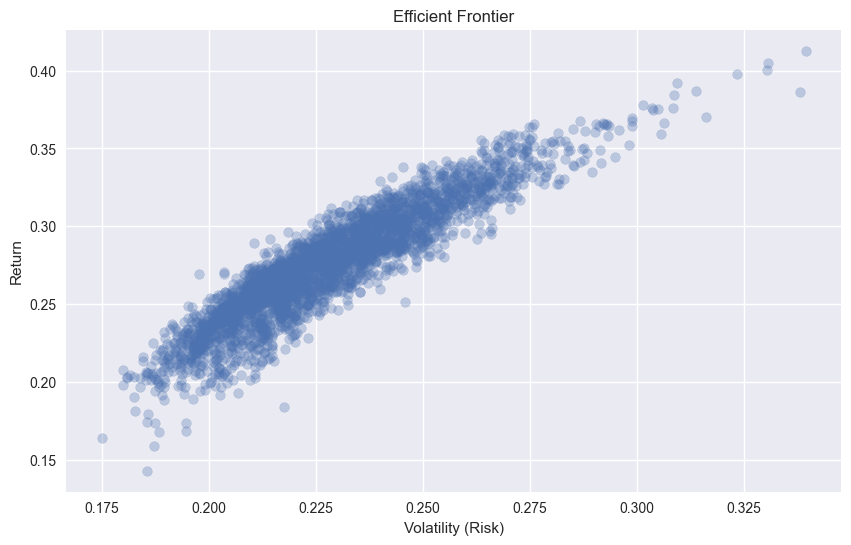

In [36]:
plt.figure(figsize=(10,6))

plt.scatter(results[:,1], results[:,0], alpha=0.3)

plt.xlabel("Volatility (Risk)")
plt.ylabel("Return")
plt.title("Efficient Frontier")

plt.grid(True)
plt.savefig(os.path.join(IMAGES_PATH, "efficient_frontier.png"))
plt.show()

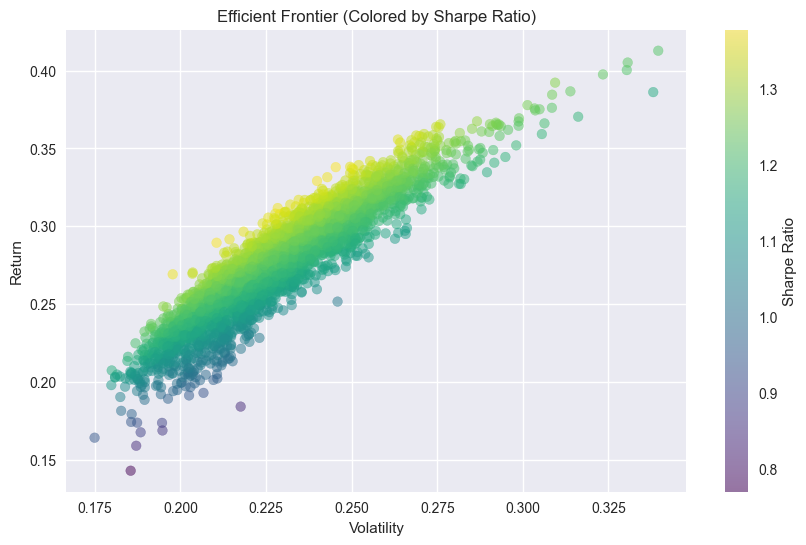

In [37]:
sharpe_values = results[:,0] / results[:,1]

plt.figure(figsize=(10,6))

plt.scatter(
    results[:,1],
    results[:,0],
    c=sharpe_values,
    cmap='viridis',
    alpha=0.5
)

plt.colorbar(label="Sharpe Ratio")

plt.xlabel("Volatility")
plt.ylabel("Return")
plt.title("Efficient Frontier (Colored by Sharpe Ratio)")

plt.grid(True)
plt.savefig(os.path.join(IMAGES_PATH, "efficient_frontier_Colored_by_Sharpe_ratio.png"))
plt.show()

## 🚀 Final Conclusion

This project demonstrates how financial data can be used to evaluate
portfolio performance, risk, and diversification.

By combining statistical analysis and visualization, we can make
informed decisions about asset allocation and portfolio construction.